<h1 align="center" style="color:#1F4E79;">AtliQo Bank Credit Card Launch: Phase 1</h1>

<h3 align="center" style="color:#1F4E79;">Target Market Analysis & Customer Insights</h3>

## Project Overview

AtliQo Bank is planning to launch a new credit card and wants to identify the most suitable customer segment to target.

This analysis focuses on understanding customer demographics, financial profiles, and transaction behavior to identify an untapped market and recommend the most suitable target audience for the new credit card.

## Business Objective

The objective of this project is to analyze existing customer data and identify the most promising customer segment for AtliQo Bank's new credit card launch.

The analysis will help answer:

- Which customer segments show the strongest potential?
- Which age group represents an untapped market?
- What customer characteristics can help guide the campaign strategy?

## Dataset Overview

The project uses three datasets that provide information about AtliQo Bank's existing customers:

- **Customers**: Customer demographics and income-related information.
- **Credit Profiles**: Customers' credit-related information.
- **Transactions**: Customers' transaction and spending behavior.

These datasets will be explored and analyzed to identify patterns that can help determine the most suitable target audience for the new credit card.

In [211]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<h1 style="color:#1F4E79;" align="center">Data Import</h1>

The project dataset is provided in CSV format. We will load the three datasets into pandas DataFrames for further exploration, cleaning, and analysis.


In [212]:
df_cust = pd.read_csv("data/customers.csv")
df_cs = pd.read_csv("data/credit_profiles.csv")
df_trans = pd.read_csv("data/transactions.csv")

### Dataset Dimensions

In [213]:
print("Customers data",df_cust.shape)
print("Credit Score data",df_cs.shape)
print("Transactions data",df_trans.shape)

Customers data (1000, 8)
Credit Score data (1004, 6)
Transactions data (500000, 7)


### Preview of the Datasets

In [214]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [215]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [216]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


<h1 style="color:#1F4E79;" align="center">Customers Table</h1>

In [217]:
df_cust.head(3)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married


In [218]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


<h2 style="color:#1F4E79;">1. Analyze Income Column</h2>

### Handle Null Values: Annual Income

I will start by checking the dataset for missing values.

In [219]:
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

There are 50 missing values in the `annual_income` column. I will first examine these records to check whether the missing values show any noticeable pattern before handling them.

In [220]:
df_cust[df_cust["annual_income"].isna()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


### Handling Missing Annual Income

I don't want to remove these 50 records because they contain other useful customer information. Since income can be different for different occupations, I will fill the missing values using the median income of each occupation.

In [221]:
occupation_wise_inc_median =  df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [222]:
occupation_wise_inc_median["Artist"]

np.float64(45794.0)

In [223]:
def get_median_value(row):
        if pd.isnull(row["annual_income"]):
            return occupation_wise_inc_median[row["occupation"]]
        else:
            return row["annual_income"]

In [224]:
df_cust["annual_income"] = df_cust.apply(get_median_value, axis=1)

In [225]:
df_cust.iloc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


The previously missing `annual_income` values for these records have now been filled using the median income of their respective occupations.

In [226]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

There are no missing values left in the dataset, so the data is ready for further analysis.

### Annual Income Distribution

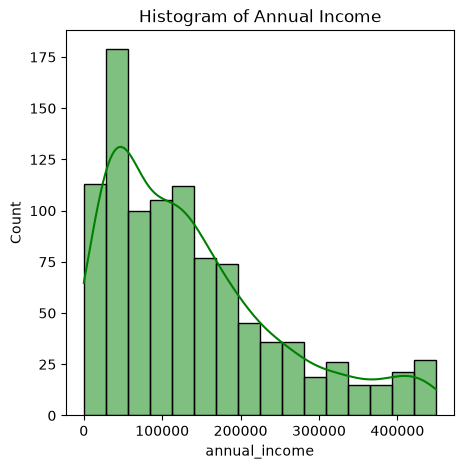

In [227]:
plt.figure(figsize= (5,5))
sns.histplot(df_cust["annual_income"], kde=True, color='green', label='Data')
plt.title("Histogram of Annual Income")
plt.show()

##### The annual income distribution is right-skewed, with most customers falling in the lower income range and fewer customers at higher income levels.

### Quick Statistics

The `describe()` function gives a quick summary of the annual income data, including the `mean`, `standard deviation`, `median`, `minimum`, and `maximum`.

In [228]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


The summary shows two unusual values that need further investigation. The `age` column ranges from 1 to 135, while `annual_income` ranges from 2 to 449,346. I will focus on the `annual_income` column first and investigate the unusually low income values.

In [229]:
df_cust[df_cust["annual_income"] < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


##### The data shows 10 customers with annual income below 100. These values are unusually low compared with the rest of the dataset, so I will replace them using the median income for each occupation.

In [230]:
occupation_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [231]:
# Replace very low income values with the median income for that occupation
for index, row in df_cust.iterrows():
    if row["annual_income"]<100:
        df_cust.at[index, "annual_income"] = occupation_wise_inc_median[row["occupation"]]

df_cust[df_cust["annual_income"] < 100]

In [232]:
df_cust.loc[[31, 316]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,261191.5,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,58017.0,Married


##### The missing income values have been replaced with the median income for their respective occupations. The final check shows that no income values below 100 are left in the dataset.

### Annual Income by Occupation

In [233]:
avg_income_per_occupation =  df_cust.groupby("occupation")["annual_income"].mean()
avg_income_per_occupation

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

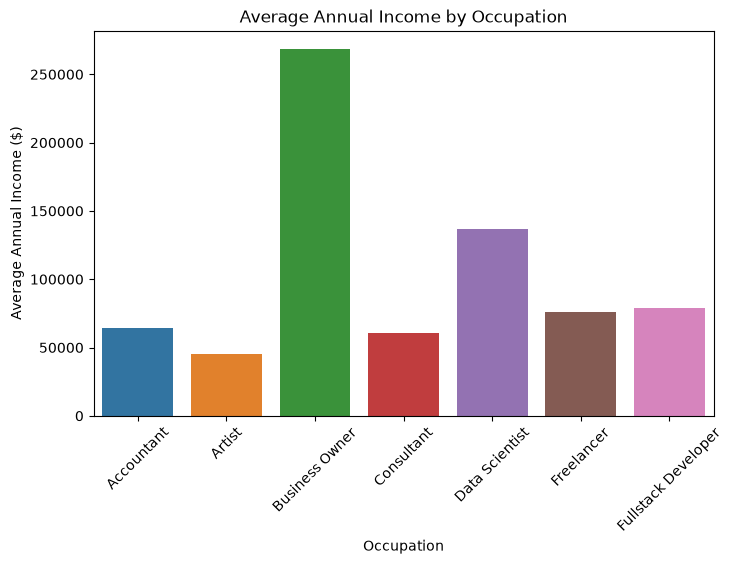

In [234]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_income_per_occupation.index, y=avg_income_per_occupation.values, palette='tab10')
plt.xticks(rotation=45)
plt.title("Average Annual Income by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Annual Income ($)")
plt.show()

### Annual Income by Customer Characteristics

I compared average annual income across gender, location, occupation, and marital status to understand how income varies across different customer groups.

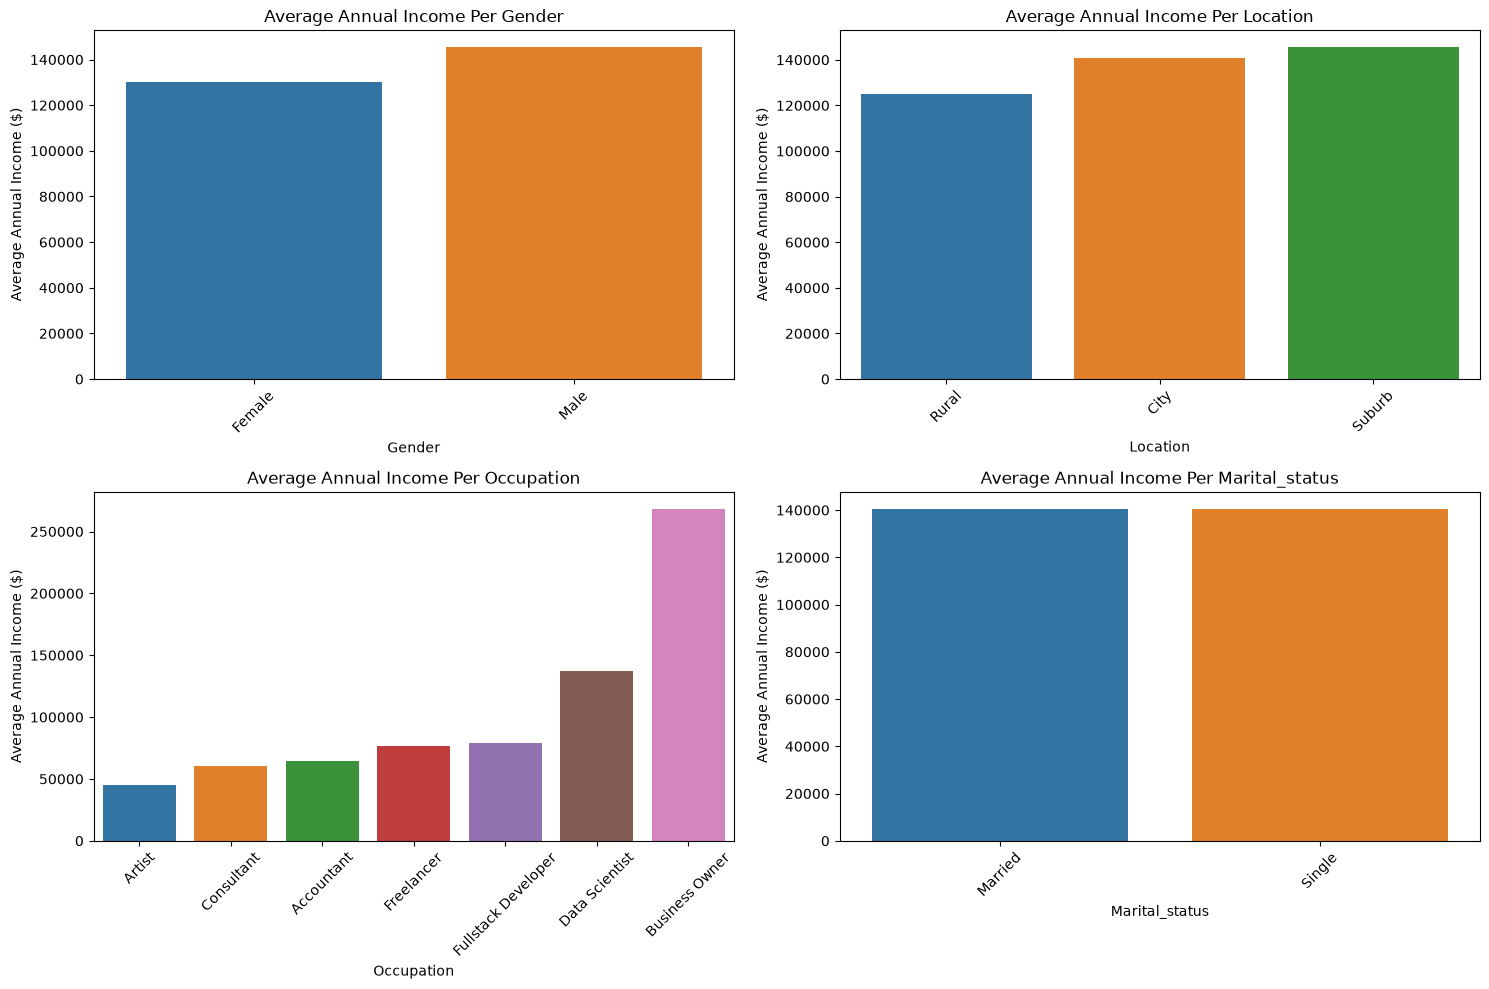

In [235]:
categorical_columns = ["gender", "location", "occupation", "marital_status"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, ax in zip(categorical_columns, axes.flat):

    avg_income_per_group = (
        df_cust.groupby(col)["annual_income"]
        .mean()
        .sort_values()
    )

    sns.barplot(
        x=avg_income_per_group.index,
        y=avg_income_per_group.values,
        palette="tab10",
        ax=ax
    )

    ax.set_title(f"Average Annual Income Per {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Average Annual Income ($)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

### Handling Null Values: Age

I will first check the `age` column for missing values before moving on to the age distribution and outlier analysis.

In [236]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [237]:
df_cust.age.describe()

count    1000.000000
mean       36.405000
std        15.666155
min         1.000000
25%        26.000000
50%        32.000000
75%        46.000000
max       135.000000
Name: age, dtype: float64

The `age` column ranges from 1 to 135, which suggests that some values may not represent realistic customer ages. I will examine the distribution to identify these unusual records.

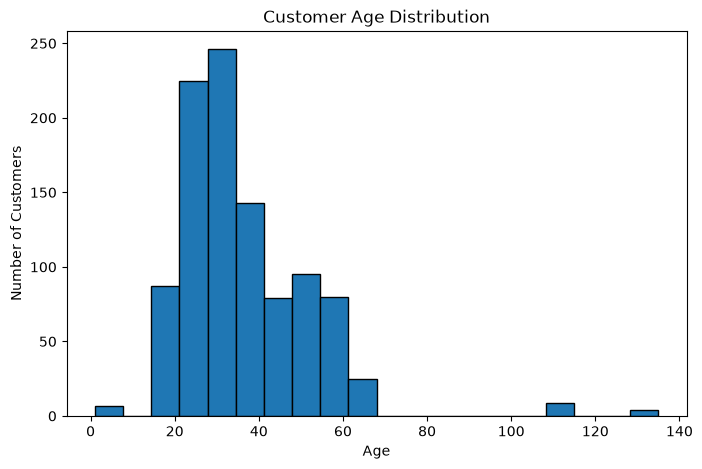

In [238]:
plt.figure(figsize=(8, 5))
plt.hist(df_cust["age"], bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

In [239]:
df_cust[(df_cust["age"] < 15) | (df_cust["age"] > 80)].shape

(20, 8)

In [240]:
outliers = df_cust[(df_cust["age"] < 15) | (df_cust["age"] > 80)]
outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married


##### There are 20 customers with ages below 15 or above 80. These values are outside the expected customer age range, so I will replace them using the median age for their respective occupations.

In [241]:
median_age_per_occupation = df_cust.groupby("occupation")["age"].median()
median_age_per_occupation

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [242]:
# Replacing unusual ages with the median age for that occupation
for index, row in outliers.iterrows():
        df_cust.at[index, "age"] = round(median_age_per_occupation[row["occupation"]])
        

In [243]:
df_cust[(df_cust["age"] < 15) | (df_cust["age"] > 80)]


,cust_id,name,gender,age,location,occupation,annual_income,marital_status


I also checked a few of the affected records to confirm that their ages were replaced with the median age for their respective occupations.

In [244]:
df_cust.iloc[[0,41,165,991]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,26,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,24,City,Freelancer,39721.0,Single
991,992,Krishna Banerjee,Male,28,City,Fullstack Developer,93267.0,Single


In [245]:
df_cust.age.describe()

count    1000.000000
mean       35.544000
std        12.275372
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

##### The age values have now been corrected, with the final age range falling between 18 and 64.

### Age Group Distribution

In [246]:
bin_edges = [17, 25, 48, 65]
bin_labels = ["18-25", "26-48", "49-65"]

df_cust["age_group"] = pd.cut(df_cust["age"], bins=bin_edges,  labels = bin_labels)

In [247]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48


In [248]:
age_group_counts = df_cust["age_group"].value_counts(normalize=True)*100
age_group_counts

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

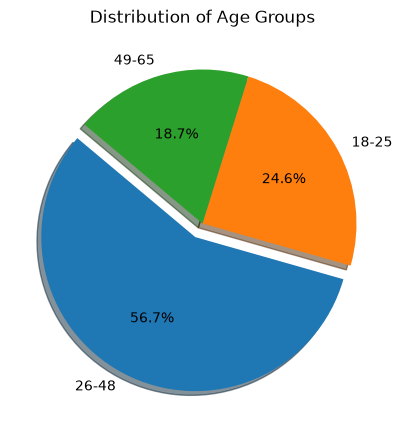

In [249]:
plt.figure(figsize=(6, 5))

plt.pie(
    age_group_counts,
    labels=age_group_counts.index,
    autopct="%1.1f%%",
    shadow=True,
    explode=(0.1, 0, 0),
    startangle=140
)

plt.title("Distribution of Age Groups")
plt.show()

##### The 26–48 age group has the highest share of customers at 56.7%. Customers aged 18–25 make up 24.6%, while the 49–65 group makes up 18.7%.

### Customer Distribution by Location and Gender

In [250]:
customer_location_gender = df_cust.groupby(["location", "gender"]).size().unstack()
customer_location_gender

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


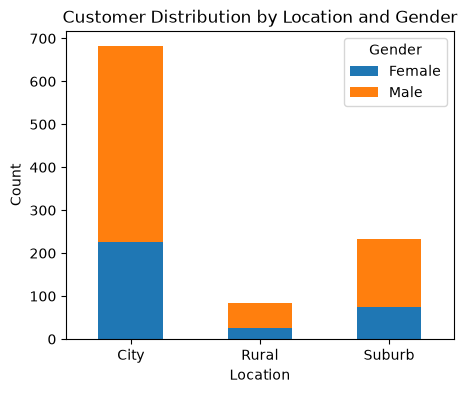

In [251]:
customer_location_gender.plot(kind='bar', stacked=True, figsize=(5,4))
plt.xticks(rotation=0)
plt.title("Customer Distribution by Location and Gender")
plt.legend(title="Gender")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

##### The City has the highest number of customers by a big margin. In all three locations, there are more male customers than female customers. Rural has the lowest number of customers.

<h1 style="color:#1F4E79" align="center">Credit Profiles</h1>

In [252]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


### Data Cleaning: Duplicate Customer Records

I will first check the number of records in the credit profiles data and compare it with the customer data.

In [253]:
df_cs.shape

(1004, 6)

The credit profiles data has 1004 records, while the customer data has 1000 customers. I will check the customer IDs to find the extra records.

In [254]:
df_cs["cust_id"].nunique()

1000

In [255]:
df_cs[df_cs["cust_id"].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


##### The duplicate customer IDs confirm that some customers have more than one record. I will keep the last record for each customer ID and use the cleaned dataframe for the next steps.

In [256]:
df_cs_clean_1=df_cs.drop_duplicates(subset="cust_id", keep='last')
df_cs_clean_1.shape

(1000, 6)

In [257]:
df_cs_clean_1[df_cs_clean_1.duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


##### The duplicate records have been removed, and the cleaned credit profiles data now has one record per customer.

### Credit Limit Analysis

I will first check the cleaned credit profiles data for missing values.

In [258]:
df_cs_clean_1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

There are 65 missing values in `credit_limit`. I will look at these records first and then check how credit limit is related to credit score.

In [259]:
df_cs_clean_1[df_cs_clean_1["credit_limit"].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [260]:
df_cs_clean_1["credit_limit"].value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

### Credit Score and Credit Limit

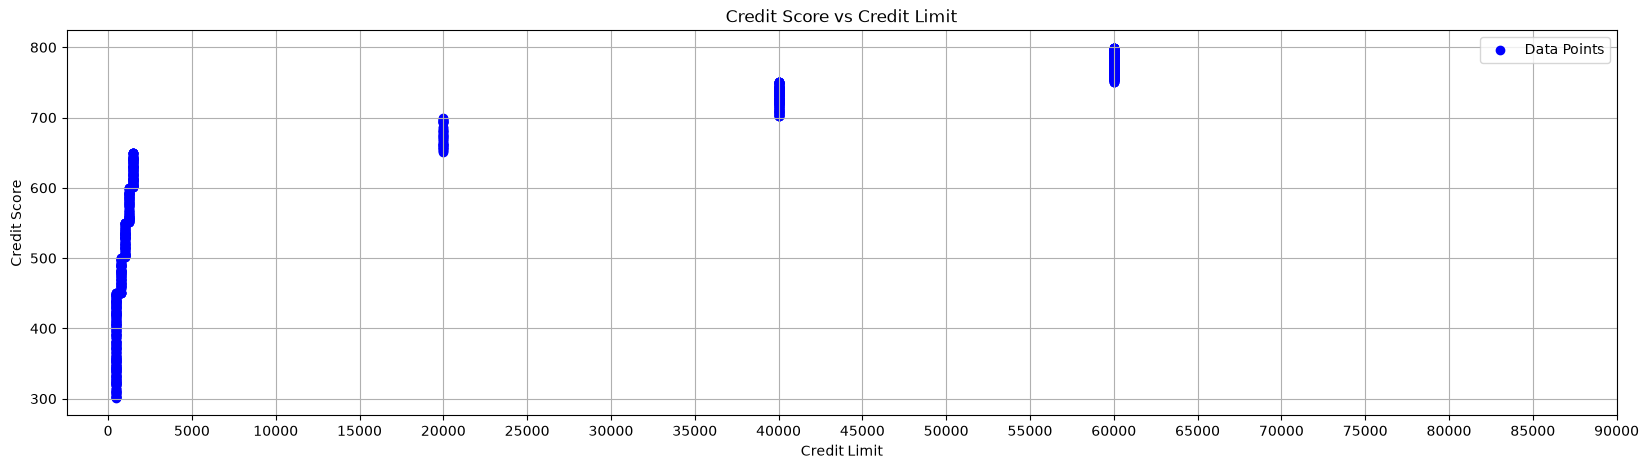

In [261]:
plt.figure(figsize= (20,5))
plt.scatter(df_cs_clean_1["credit_limit"], df_cs_clean_1["credit_score"], c='blue', marker='o', label = "Data Points")
plt.title("Credit Score vs Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Credit Score")

plt.xticks(range(0, 90001, 5000))
plt.grid(True)

plt.legend()
plt.show()

In [262]:
# Grouping credit scores into ranges
bin_ranges = [300, 450, 500, 550, 600, 650, 700, 750, 800]

bin_labels = [f"{start}-{end-1}" for start, end in zip(bin_ranges, bin_ranges[1:])]

df_cs_clean_1["credit_score_range"] = pd.cut(df_cs_clean_1["credit_score"], bins=bin_ranges, labels=bin_labels, include_lowest=True, right=False)
df_cs_clean_1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [263]:
df_cs_clean_1[df_cs_clean_1["credit_score_range"] == "700-749"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
4,5,708,0.586151,18090.0,2.0,40000.0,700-749
6,7,747,0.523965,15544.0,4.0,40000.0,700-749
16,17,702,0.894423,18444.0,0.0,40000.0,700-749
27,28,729,0.149748,3453.0,2.0,40000.0,700-749
...,...,...,...,...,...,...,...
969,966,720,0.203742,6159.0,4.0,40000.0,700-749
970,967,739,0.845474,23929.0,4.0,40000.0,700-749
991,988,739,0.435891,9283.0,4.0,40000.0,700-749
994,991,709,0.718484,15473.0,4.0,40000.0,700-749


In [264]:
mode_df = df_cs_clean_1.groupby("credit_score_range")["credit_limit"].agg(lambda x: x.mode().iloc[0]).reset_index()
mode_df

,credit_score_range,credit_limit
0,300-449,500.0
1,450-499,750.0
2,500-549,1000.0
3,550-599,1250.0
4,600-649,1500.0
5,650-699,20000.0
6,700-749,40000.0
7,750-799,60000.0


In [265]:
df_cs_clean_1[df_cs_clean_1["credit_limit"].isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
680,677,300,0.785509,341.0,1.0,NaN,300-449
159,160,709,0.759795,18244.0,0.0,NaN,700-749
414,415,646,0.503281,533.0,3.0,NaN,600-649


In [266]:
df_cs_clean_2 = pd.merge(df_cs_clean_1, mode_df, on = "credit_score_range", suffixes=("","_mode"))
df_cs_clean_2.sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
988,989,497,0.762646,295.0,4.0,750.0,450-499,750.0
629,630,619,0.598746,716.0,1.0,1500.0,600-649,1500.0
818,819,643,0.740503,862.0,0.0,1500.0,600-649,1500.0


In [267]:
df_cs_clean_2[df_cs_clean_2["credit_limit"].isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
211,212,337,0.608700,226.0,4.0,NaN,300-449,500.0
477,478,757,0.160767,6286.0,2.0,NaN,750-799,60000.0
505,506,722,0.745946,25243.0,3.0,NaN,700-749,40000.0


In [268]:
df_cs_clean_3 = df_cs_clean_2.copy()
df_cs_clean_3["credit_limit"] = df_cs_clean_3["credit_limit"].fillna(df_cs_clean_2["credit_limit_mode"])

In [269]:
df_cs_clean_3.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

##### The missing credit limits are now filled based on the credit score range of each customer.

In [270]:
df_cs_clean_3.iloc[[467, 399, 190]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
467,468,354,0.892740,231.0,2.0,500.0,300-449,500.0
399,400,754,0.884299,32031.0,2.0,60000.0,750-799,60000.0
190,191,794,0.340700,16522.0,0.0,60000.0,750-799,60000.0


### Handle Outliers: Outstanding Debt

In [271]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.00000,60000.000000


The `outstanding_debt` values also need a closer look because some customers have debt higher than their credit limit.

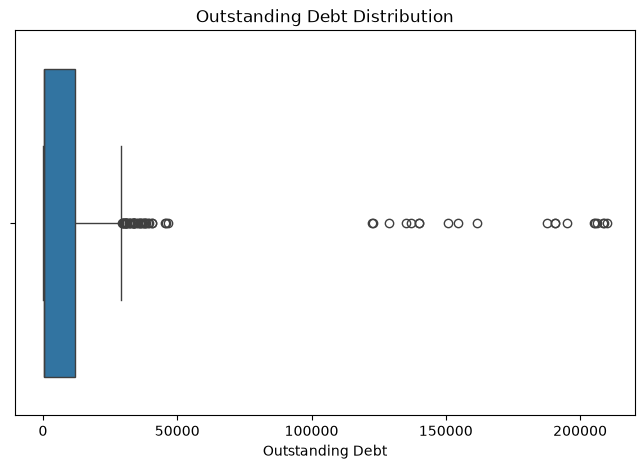

In [272]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cs_clean_3["outstanding_debt"])
plt.title("Outstanding Debt Distribution")
plt.xlabel("Outstanding Debt")
plt.show()

In [273]:
df_cs_clean_3[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750-799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700-749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750-799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300-449,500.0


In [274]:
# Replacing debt values that exceed the credit limit with the credit limit
df_cs_clean_3.loc[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"], "outstanding_debt"] = df_cs_clean_3["credit_limit"]

In [275]:
df_cs_clean_3[df_cs_clean_3["outstanding_debt"] > df_cs_clean_3["credit_limit"]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [276]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.00000,60000.000000


In [277]:
df_cs_clean_3.loc[[1,19,25]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,1500.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,60000.0,2.0,60000.0,750-799,60000.0


### Relationship Between Credit Profile Variables

In [278]:
df_cs_clean_3.head(2)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0


In [279]:
df_cust.head(2)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48


In [280]:
df_merged = df_cust.merge(df_cs_clean_3, on="cust_id", how="inner")
df_merged.head(2)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0


In [281]:
numerical_cols = ["credit_score", "credit_utilisation", "outstanding_debt", "credit_limit", "annual_income", "age"]

correlation_matrix = df_merged[numerical_cols].corr()
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.847952,0.575751,0.444870
credit_utilisation,-0.070445,1.000000,0.192838,-0.080493,-0.086368,-0.027598
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661,0.444223
credit_limit,0.847952,-0.080493,0.810581,1.000000,0.684775,0.510891
annual_income,0.575751,-0.086368,0.555661,0.684775,1.000000,0.618965
age,0.444870,-0.027598,0.444223,0.510891,0.618965,1.000000


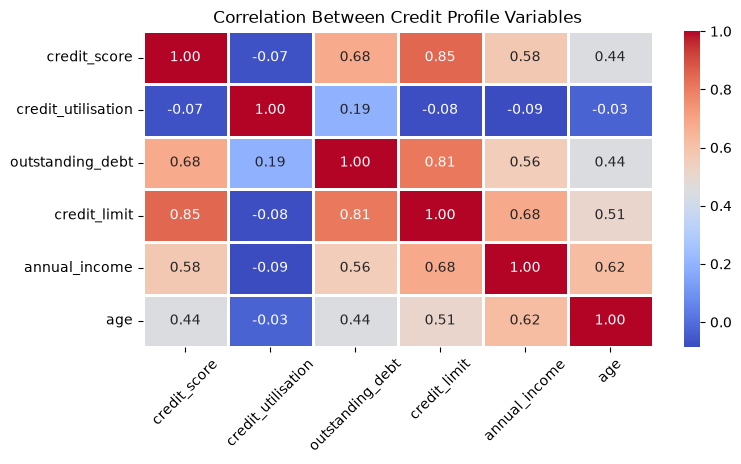

In [282]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.8)
plt.title("Correlation Between Credit Profile Variables")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

##### Credit score and credit limit have the strongest relationship here (0.85). Annual income also has a fairly strong relationship with credit limit (0.68). Credit utilisation, on the other hand, does not show much relationship with the other variables.

<h1 style="color:#1F4E79" align="center">Transactions Table</h1>

In [283]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


### Handle Missing Values: Platform

In [284]:
df_trans.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [285]:
df_trans[df_trans["platform"].isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


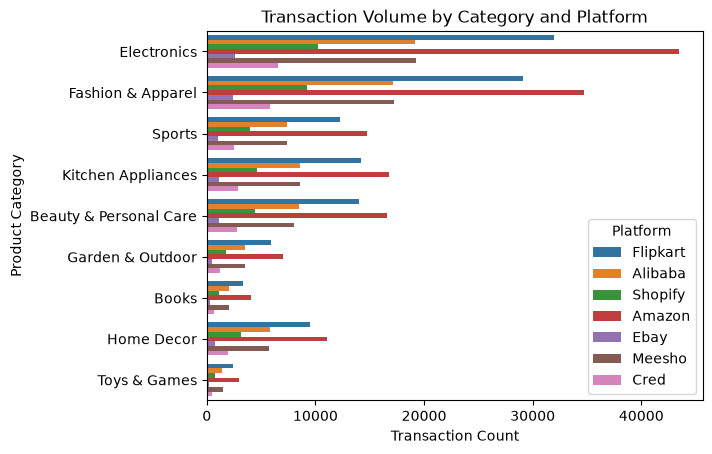

In [286]:
sns.countplot(y="product_category", hue = "platform", data=df_trans)
plt.xlabel("Transaction Count")
plt.ylabel("Product Category")
plt.legend(title="Platform")
plt.title("Transaction Volume by Category and Platform")

plt.show()

##### Amazon is the most commonly used platform across the product categories, so I used it to fill the missing platform values.

In [287]:
df_trans["platform"].mode()[0]

'Amazon'

In [288]:
df_trans["platform"] = df_trans["platform"].fillna(df_trans["platform"].mode()[0])

In [289]:
df_trans.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

In [290]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


##### The summary shows some transactions with an amount of 0, so I will look at these records and check where they are coming from.

In [291]:
df_trans[df_trans["tran_amount"] == 0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499326,499327,695,2023-09-05,0,Amazon,Electronics,Credit Card
499494,499495,295,2023-09-05,0,Amazon,Electronics,Credit Card
499708,499709,141,2023-09-05,0,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [292]:
df_trans_zero = df_trans[df_trans["tran_amount"] == 0]
df_trans_zero.shape

(4734, 7)

In [293]:
df_trans_zero["platform"].value_counts()

platform
Amazon    4734
Name: count, dtype: int64

In [294]:
df_trans_zero[["payment_type", "product_category", "platform"]].value_counts()

payment_type  product_category  platform
Credit Card   Electronics       Amazon      4734
Name: count, dtype: int64

##### All zero-amount transactions are from Amazon, under Electronics, and paid by Credit Card. I will use this same group to find a suitable value for replacing the zero amounts.

In [295]:
df_trans_1 = df_trans[(df_trans["platform"] == "Amazon") & (df_trans["product_category"] == "Electronics") & (df_trans["payment_type"] == "Credit Card")]
df_trans_1.shape

(15637, 7)

In [296]:
median_to_replace = df_trans_1[df_trans_1["tran_amount"] > 0]["tran_amount"].median()
median_to_replace

np.float64(554.0)

##### I will use the median of the non-zero transactions in this group to replace the zero amounts, since the transaction values contain some unusually high values.

In [297]:
df_trans["tran_amount"] = df_trans["tran_amount"].replace(0, median_to_replace)

In [298]:
df_trans[df_trans["tran_amount"] == 0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


In [299]:
Q1, Q3 = df_trans["tran_amount"].quantile((0.25, 0.75))
IQR = Q3-Q1


lower = Q1 - 2*IQR
upper = Q3 + 2*IQR

lower, upper

(-628.0, 1107.0)

In [300]:
df_tran_outliers = df_trans[df_trans["tran_amount"]>upper]
df_tran_outliers.head(2)

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay


In [301]:
df_trans_normal = df_trans[df_trans["tran_amount"] < upper]
df_trans_normal.head(2)

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card


In [302]:
trans_mean_per_category = df_trans_normal.groupby("product_category")["tran_amount"].mean()
trans_mean_per_category

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [303]:
df_trans["tran_amount"] = df_trans["tran_amount"].astype(float)

In [304]:
df_trans.loc[df_tran_outliers.index, "tran_amount"] = df_tran_outliers["product_category"].map(trans_mean_per_category)

In [305]:
df_trans.loc[df_tran_outliers.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.333298,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.773288,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,64.553463,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,64.553463,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,64.553463,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,269.181631,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,269.181631,Meesho,Sports,Gpay


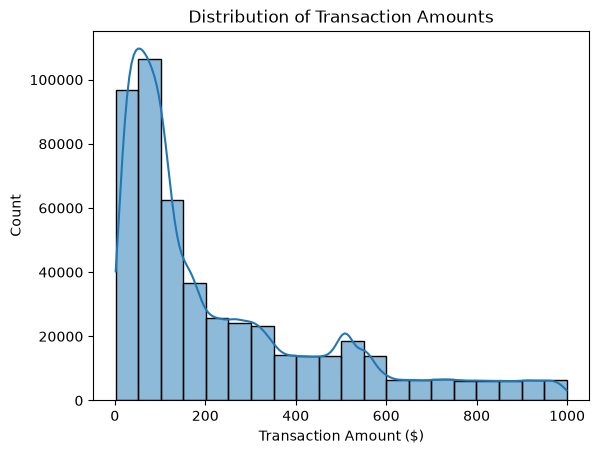

In [306]:
sns.histplot(df_trans["tran_amount"], kde=True, bins=20)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount ($)")
plt.show()

##### Most transaction amounts are below $1,000, and the distribution is still right-skewed.

In [307]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking


In [308]:
df_trans.payment_type.value_counts()

payment_type
Phonepe        144228
Credit Card    139778
Gpay           109218
Debit Card      59500
Net Banking     43223
Cash             4053
Name: count, dtype: int64

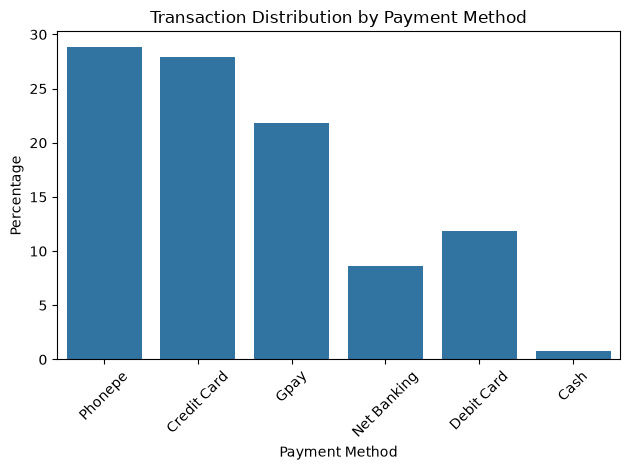

In [309]:
sns.countplot(x=df_trans.payment_type, stat='percent')
plt.title("Transaction Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [310]:
df_merged_2 = pd.merge(df_trans, df_merged, on="cust_id", how="inner")
df_merged_2.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type,name,gender,age,...,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe,Swara Bali,Female,22,...,47403.0,Married,18-25,533,0.289353,189.0,2.0,1000.0,500-549,1000.0
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card,Ayush Rastogi,Male,35,...,137381.0,Single,26-48,666,0.789690,13470.0,4.0,20000.0,650-699,20000.0
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe,Kriti Joshi,Male,24,...,51629.0,Married,18-25,600,0.509649,551.0,0.0,1250.0,600-649,1500.0
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay,Sia Duggal,Male,20,...,51602.0,Married,18-25,606,0.676312,560.0,0.0,1500.0,600-649,1500.0
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking,Ananya Kadam,Male,22,...,43783.0,Married,18-25,394,0.785495,266.0,1.0,500.0,300-449,500.0


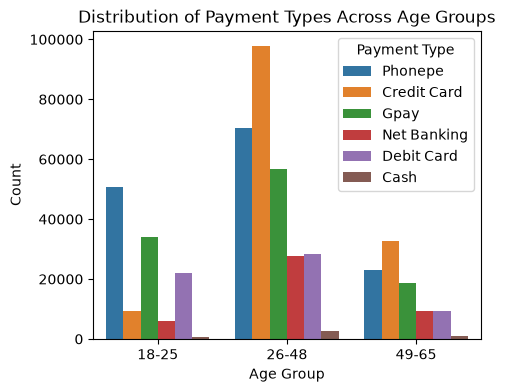

In [311]:
plt.figure(figsize=(5,4))
sns.countplot(x="age_group", hue="payment_type", data=df_merged_2)
plt.title("Distribution of Payment Types Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title='Payment Type', loc="upper right")
plt.show()

##### The 18-25 age group uses Credit Card much less than the other payment methods, while PhonePe and GPay are more commonly used.

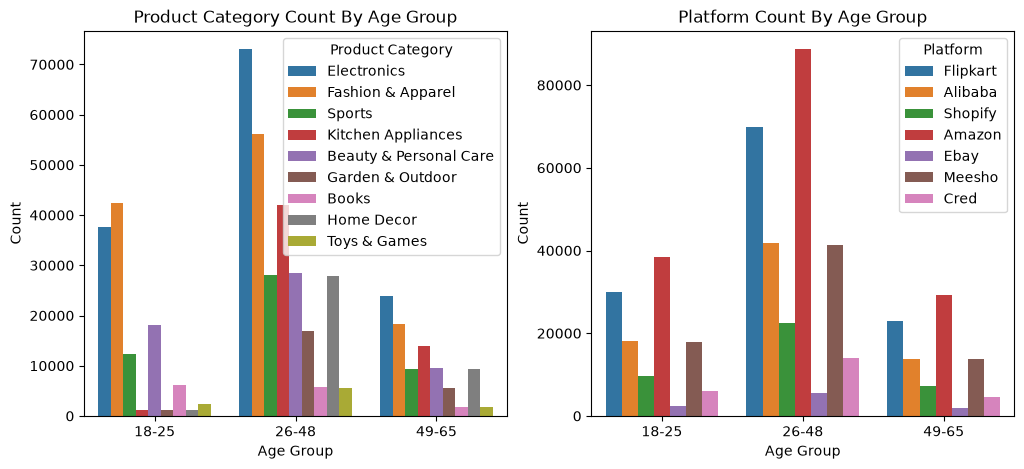

In [312]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
sns.countplot(x="age_group", hue="product_category", data=df_merged_2, ax=ax1)
ax1.set_title("Product Category Count By Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax1.legend(title="Product Category", loc="upper right")

sns.countplot(x="age_group", hue="platform", data=df_merged_2, ax=ax2)
ax2.set_title("Platform Count By Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Count")
ax2.legend(title="Platform", loc="upper right")
plt.show()

##### Electronics and Fashion & Apparel are the most common product categories across the age groups. The 18–25 group mostly purchases Fashion & Apparel and Electronics, while the 26–48 group has the highest number of purchases overall. The 49–65 group has fewer transactions across most categories.

##### Amazon is the most commonly used platform across all three age groups, followed by Flipkart. The 26–48 group has the highest number of transactions on most platforms, while the 18–25 and 49–65 groups have much fewer transactions.

### Data Visualization: Average Transaction Amount

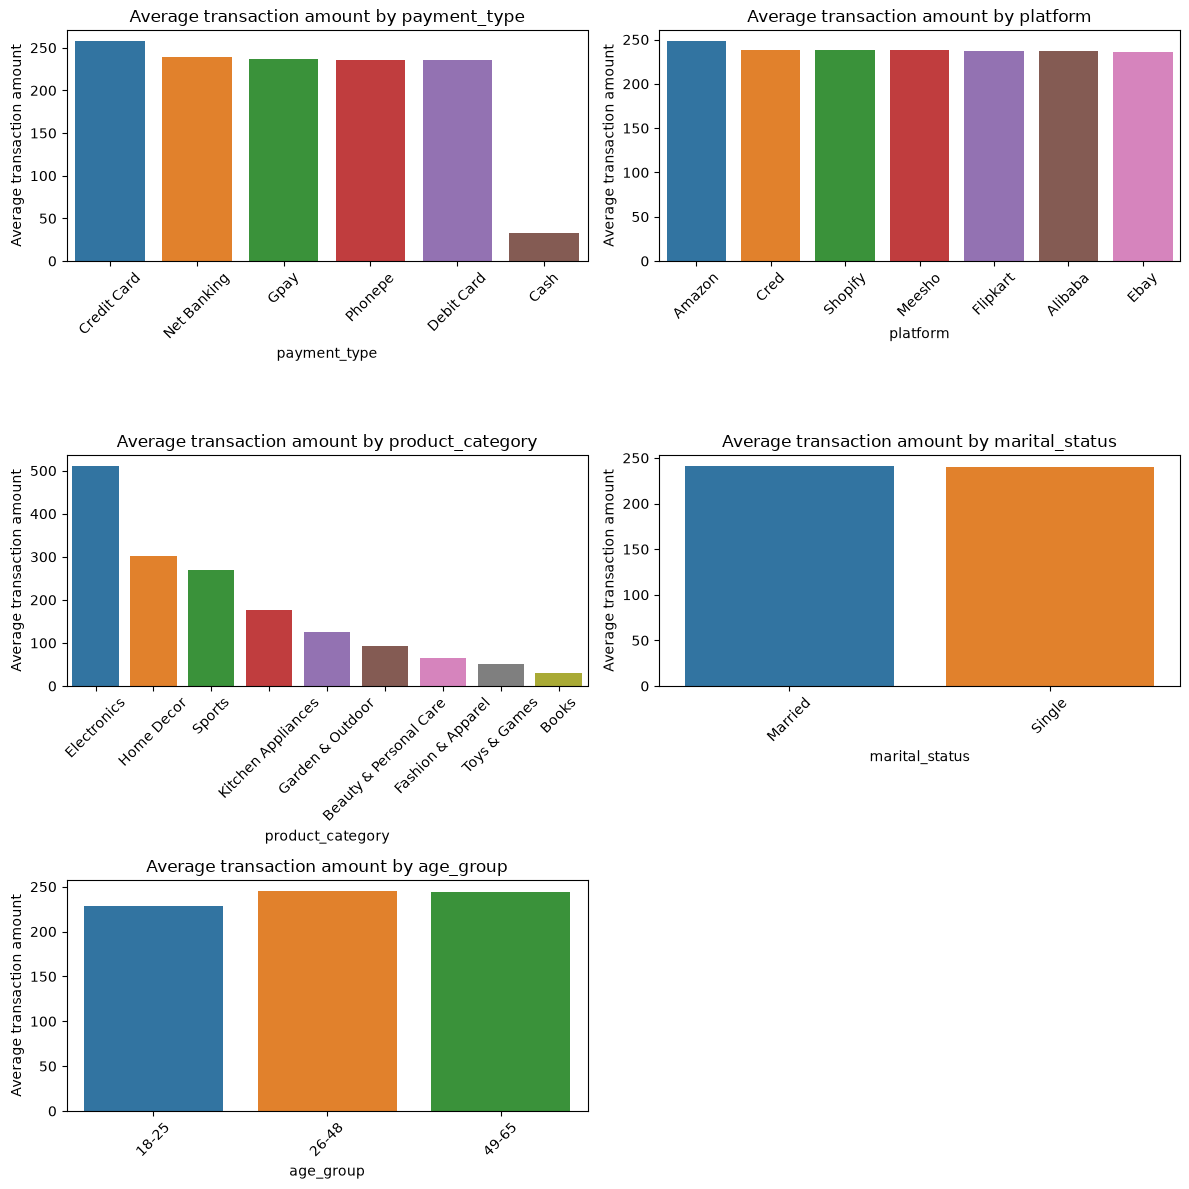

In [313]:
cat_cols = ["payment_type", "platform", "product_category", "marital_status", "age_group"]

num_rows = 3
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

axes = axes.flatten()

for i, cat_col in enumerate(cat_cols):
    avg_tran_amount_by_category = df_merged_2.groupby(cat_col)["tran_amount"].mean().reset_index()
    sorted_data = avg_tran_amount_by_category.sort_values(by="tran_amount", ascending=False)

    sns.barplot(x=cat_col, y="tran_amount", data=sorted_data, ci=None, ax=axes[i], palette="tab10")
    axes[i].set_title(f"Average transaction amount by {cat_col}")
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel("Average transaction amount")

    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Further Analysis on Age Group

In [314]:
# Calculating average income, credit limit, and credit score for each age group
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

,age_group,annual_income,credit_limit,credit_score
0,18-25,37091.235772,1130.081301,484.451220
1,26-48,145869.623457,20560.846561,597.569665
2,49-65,260165.925134,41699.197861,701.524064


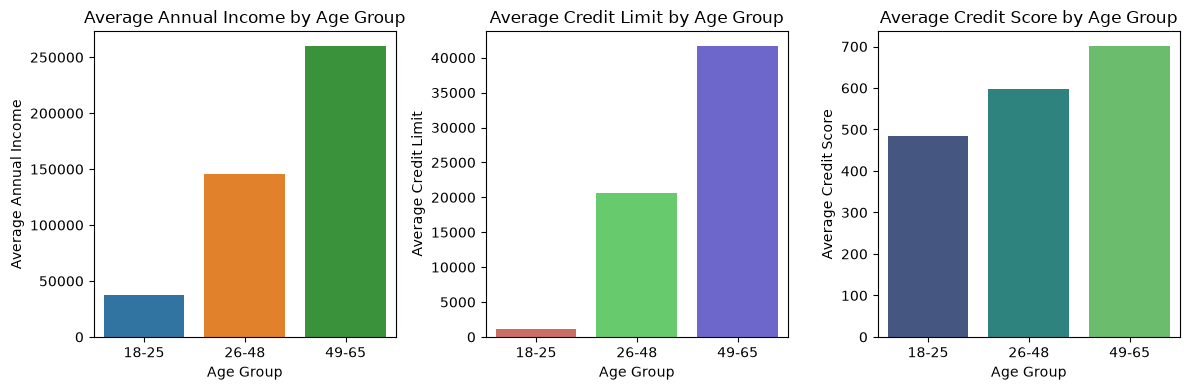

In [315]:
# Creating subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Average Max Credit Limit by Age Group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
ax2.set_title('Average Credit Limit by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Credit Limit')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Average Credit Score by Age Group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)
ax3.set_title('Average Credit Score by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Credit Score')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##### As age increases, average income, credit limit, and credit score also increase. The 18-25 group has the lowest values across all three, while the 49-65 group has the highest.

<h2 align="center" style="color:#1F4E79">Finalize Target Market For a Trial Credit Card Launch</h2>

#### Targeting Untapped Market

1. The 18-25 age group makes up around 26% of the customers in our data.

2. Their average annual income is below $50K.

3. This group has lower credit scores and credit limits, which suggests they have less credit history.

4. Credit card usage is lower in this age group compared to the older groups.

5. Their top three product categories are Electronics, Fashion & Apparel, and Beauty & Personal Care.